# **Proyecto:** Detección de Cambios en Interfaces Web para RPA usando IA

# 4. Estrategias de Balanceamiento

Mitigar el desbalance de clases para mejorar el rendimiento del modelo YOLOv8, evitando sesgo hacia clases mayoritarias.


In [34]:
from datasets import load_dataset
from huggingface_hub import snapshot_download
from huggingface_hub import login
from getpass import getpass

# 1. Montar Google Drive para usar el dataset desde ahi
from google.colab import drive
drive.mount('/content/drive')

repo_path = "/content/drive/MyDrive/MIA/Dataset"
print("Dataset descargado en:", repo_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset descargado en: /content/drive/MyDrive/MIA/Dataset


## Análisis de desbalance

Este análisis permite visualizar la distribución de instancias por clase dentro del conjunto de entrenamiento. Es útil para identificar si existe un desbalance de clases que pueda afectar el rendimiento del modelo YOLOv8.

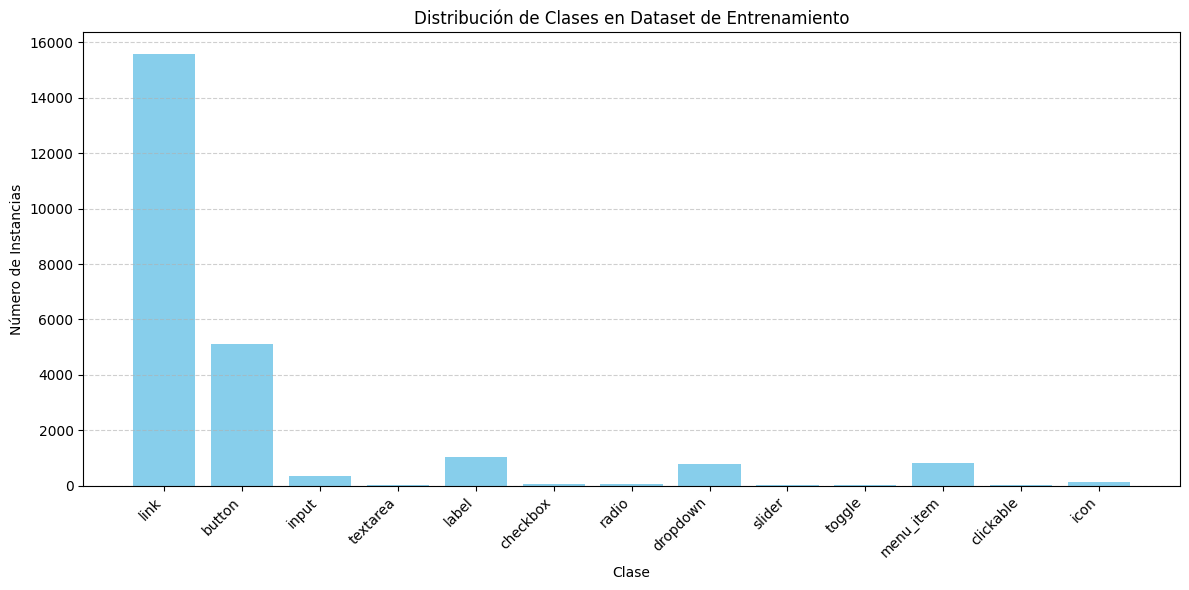

In [35]:
import os
from collections import Counter
import matplotlib.pyplot as plt

# Ruta a las etiquetas
label_dir = "/content/drive/MyDrive/MIA/Dataset/train/labels"

# Diccionario de nombres de clases
class_names = {
    0: "link",
    1: "button",
    2: "input",
    3: "select",
    4: "textarea",
    5: "label",
    6: "checkbox",
    7: "radio",
    8: "dropdown",
    9: "slider",
    10: "toggle",
    11: "menu_item",
    12: "clickable",
    13: "icon",
    14: "image",
    15: "text"
}

# Contador de instancias por clase
class_counts = Counter()

# Recorrer archivos de etiquetas
for file_name in os.listdir(label_dir):
    if file_name.endswith(".txt"):
        with open(os.path.join(label_dir, file_name), 'r') as f:
            for line in f:
                class_id = int(line.strip().split()[0])
                class_counts[class_id] += 1

# Ordenar clases por ID
sorted_class_ids = sorted(class_counts.keys())
counts = [class_counts[i] for i in sorted_class_ids]
labels = [class_names[i] for i in sorted_class_ids]

# Gráfico
plt.figure(figsize=(12, 6))
plt.bar(labels, counts, color='skyblue')
plt.xlabel('Clase')
plt.ylabel('Número de Instancias')
plt.title('Distribución de Clases en Dataset de Entrenamiento')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



**Interpretación**

El dataset tiene un fuerte desbalance de clases, con las clases "link" y "button" muy sobrerrepresentadas. Esto puede comprometer el rendimiento general del modelo YOLOv8, especialmente en clases menos frecuentes.

Es altamente recomendable aplicar estrategias de balanceo, enfocadas en aumentar la visibilidad de clases minoritarias para que el modelo pueda generalizar mejor.

## Técnicas de Undersampling

Reducir la cantidad de ejemplos de clases mayoritarias (por ejemplo, link y button) para mitigar su dominio en el entrenamiento.

Backup del dataset original creado en 'train_original/labels'.
Total de imágenes eliminadas (solo clases {0, 1}): 192
Dataset balanceado copiado a /content/drive/MyDrive/MIA/Dataset/train_balanced/labels


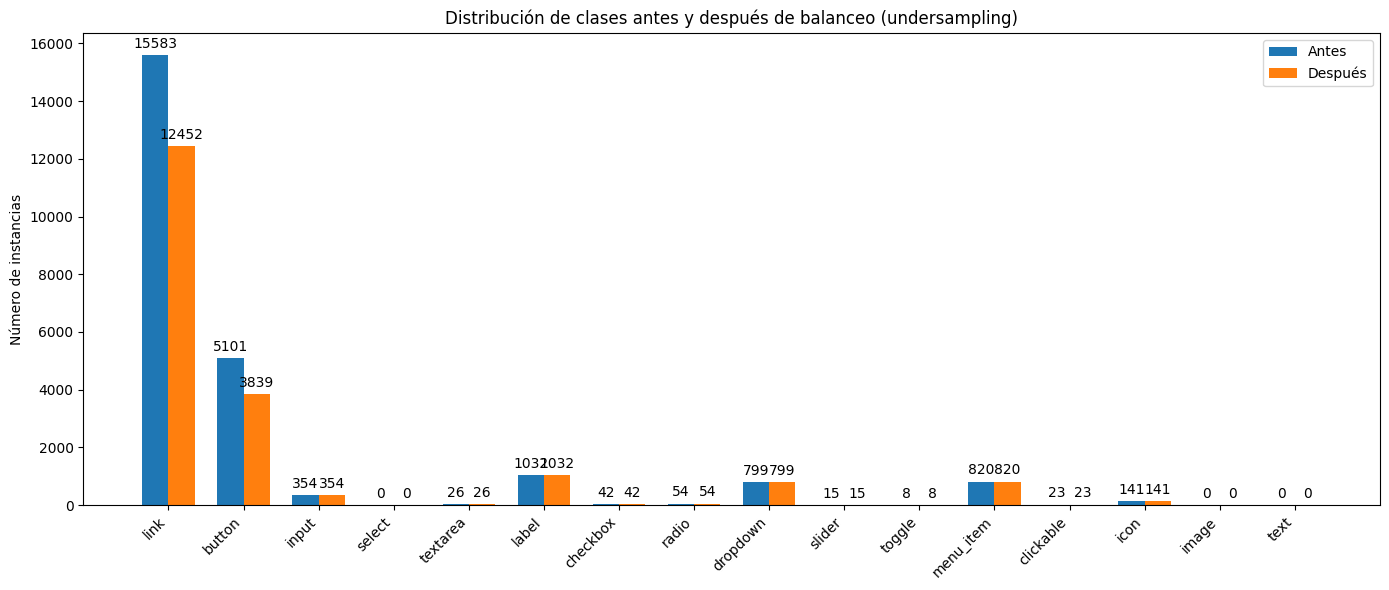

In [36]:
import os
import shutil
from collections import Counter
import matplotlib.pyplot as plt

# --- Paso 0: Respaldar dataset original (solo la primera vez) ---
# Para mantener una copia del dataset original para el conteo "antes"
src_labels_original = "/content/drive/MyDrive/MIA/Dataset/train/labels"
backup_labels_dir = "/content/drive/MyDrive/MIA/Dataset/train_original/labels"

if not os.path.exists(backup_labels_dir):
    shutil.copytree(src_labels_original, backup_labels_dir)
    print("Backup del dataset original creado en 'train_original/labels'.")

# --- Paso 1: Undersampling (mover etiquetas e imágenes con solo clases dominantes) ---
label_dir = "/content/drive/MyDrive/MIA/Dataset/train/labels"
image_dir = "/content/drive/MyDrive/MIA/Dataset/train/images"

clases_dominantes = {0, 1}  # Ejemplo: 'link' y 'button'

removed_labels_dir = os.path.join(label_dir, "removed")
removed_images_dir = os.path.join(image_dir, "removed")

os.makedirs(removed_labels_dir, exist_ok=True)
os.makedirs(removed_images_dir, exist_ok=True)

eliminadas = 0

for label_file in os.listdir(label_dir):
    if not label_file.endswith(".txt"):
        continue

    label_path = os.path.join(label_dir, label_file)
    image_name = label_file.replace(".txt", ".png")  # Ajustar extensión si es necesario
    image_path = os.path.join(image_dir, image_name)

    classes_in_image = set()
    with open(label_path, 'r') as f:
        for line in f:
            if line.strip():
                class_id = int(line.strip().split()[0])
                classes_in_image.add(class_id)

    if classes_in_image.issubset(clases_dominantes):
        # Mover etiquetas e imágenes a carpeta removed
        shutil.move(label_path, os.path.join(removed_labels_dir, label_file))
        if os.path.exists(image_path):
            shutil.move(image_path, os.path.join(removed_images_dir, image_name))
        eliminadas += 1

print(f"Total de imágenes eliminadas (solo clases {clases_dominantes}): {eliminadas}")

# --- Paso 2: Copiar dataset modificado a carpeta de dataset balanceado ---

dst_labels = "/content/drive/MyDrive/MIA/Dataset/train_balanced/labels"
if os.path.exists(dst_labels):
    shutil.rmtree(dst_labels)  # Limpiar carpeta si existe
shutil.copytree(label_dir, dst_labels)
print(f"Dataset balanceado copiado a {dst_labels}")

# --- Funciones para contar clases y graficar ---

def contar_clases_en_labels(label_dir, num_clases):
    class_counts = Counter()
    for label_file in os.listdir(label_dir):
        if not label_file.endswith('.txt'):
            continue
        with open(os.path.join(label_dir, label_file), 'r') as f:
            for line in f:
                if line.strip():
                    class_id = int(line.strip().split()[0])
                    class_counts[class_id] += 1
    for i in range(num_clases):
        if i not in class_counts:
            class_counts[i] = 0
    return [class_counts[i] for i in range(num_clases)]

def plot_distribuciones(class_names, counts_before, counts_after):
    import numpy as np

    x = np.arange(len(class_names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(14,6))
    bars_before = ax.bar(x - width/2, counts_before, width, label='Antes')
    bars_after = ax.bar(x + width/2, counts_after, width, label='Después')

    ax.set_ylabel('Número de instancias')
    ax.set_title('Distribución de clases antes y después de balanceo (undersampling)')
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.legend()

    def autolabel(bars):
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom')
    autolabel(bars_before)
    autolabel(bars_after)

    plt.tight_layout()
    plt.show()

# --- Parámetros ---

num_clases = 16
class_names = [
    'link', 'button', 'input', 'select', 'textarea', 'label', 'checkbox', 'radio',
    'dropdown', 'slider', 'toggle', 'menu_item', 'clickable', 'icon', 'image', 'text'
]

# --- Paso 3: Contar y graficar antes y después ---

counts_before = contar_clases_en_labels(backup_labels_dir, num_clases)
counts_after = contar_clases_en_labels(dst_labels, num_clases)

plot_distribuciones(class_names, counts_before, counts_after)


**Interpretación**

**Reducción significativa en clases mayoritarias:**

- La clase link se redujo de 15,583 instancias a 12,452, es decir, una reducción de aproximadamente un 20.1%.
- La clase button disminuyó de 5,101 a 3,839 instancias, lo que representa una reducción del 24.7%.

**Clases con igual número de instancias antes y después:**

- Clases como input (354), label (1,032), checkbox (42), radio (54), dropdown (799), slider (15), toggle (8), menu_item (820), clickable (23), icon (141), no cambiaron en número tras el balanceo, lo que indica que no se aplicó undersampling en estas categorías, probablemente porque ya estaban equilibradas o tenían pocos datos.

**Clases sin datos disponibles:**

- Las clases select, image y text tienen cero instancias tanto antes como después, lo que significa que no hay muestras de estas clases en el dataset.

**Balanceo más agresivo en clases mayoritarias:**

- Las dos clases con mayor cantidad de datos (link y button) muestran reducciones claras, mientras que las clases minoritarias se mantienen igual. Esto refleja que el undersampling se aplicó para mitigar el desbalance sin perder datos importantes en clases pequeñas.

#Técnicas de Oversampling

Aumentar la cantidad de ejemplos de clases minoritarias sin simplemente duplicar datos.

- Random Oversampling: Duplicar imágenes que contengan clases poco representadas.

In [38]:
import os
import shutil
from collections import Counter
import random

# Carpetas originales balanceadas (después de undersampling)
label_dir = "/content/drive/MyDrive/MIA/Dataset/train_balanced/labels"
image_dir = "/content/drive/MyDrive/MIA/Dataset/train_balanced/images"

# Clases minoritarias a oversamplear (por ejemplo)
clases_minor = {2, 3, 4}  # input, select, textarea por ejemplo

# Cuántas copias extra queremos crear por imagen minoritaria
num_copies = 3

# Contar cuántas imágenes tienen solo clases minoritarias
files_to_duplicate = []

for label_file in os.listdir(label_dir):
    if not label_file.endswith('.txt'):
        continue

    label_path = os.path.join(label_dir, label_file)
    with open(label_path, 'r') as f:
        classes_in_image = set(int(line.split()[0]) for line in f if line.strip())

    # Si todas las clases en la imagen son minoritarias
    if classes_in_image.issubset(clases_minor):
        files_to_duplicate.append(label_file)

print(f"Archivos minoritarios para duplicar: {len(files_to_duplicate)}")

# Duplicar archivos
for label_file in files_to_duplicate:
    base_name = label_file.replace('.txt', '')
    label_path = os.path.join(label_dir, label_file)
    image_path = os.path.join(image_dir, base_name + ".png")  # ajustar extensión si es necesario

    for i in range(num_copies):
        new_label_name = f"{base_name}_dup{i}.txt"
        new_image_name = f"{base_name}_dup{i}.png"

        shutil.copy(label_path, os.path.join(label_dir, new_label_name))
        shutil.copy(image_path, os.path.join(image_dir, new_image_name))

print("Oversampling por duplicación completado.")



Archivos minoritarios para duplicar: 0
Oversampling por duplicación completado.


**Interpretación**

El mensaje "Archivos minoritarios para duplicar: 0" significa que, según el código que ejecutaste para detectar imágenes que contienen solo clases minoritarias, no se encontraron archivos que cumplan esa condición en la carpeta que revisaste.

## Técnicas Híbridas

YOLO trabaja con imágenes y etiquetas en formato de coordenadas, donde cada etiqueta describe un objeto con la siguiente información:
(clase, x_center, y_center, width, height), que indica la clase del objeto y la ubicación relativa y tamaño del bounding box en la imagen.

Por otro lado, SMOTE, ENN y Tomek Links son técnicas diseñadas para operar sobre datos tabulares numéricos, típicamente en problemas de clasificación donde cada muestra es un vector de características fijas y una etiqueta.

Estas técnicas generan nuevas muestras o eliminan muestras problemáticas basándose en la distribución numérica de las características.

No funcionan directamente con datos de imagen ni con etiquetas de bounding boxes, porque:

- No consideran la estructura espacial y visual de las imágenes.

- No pueden crear nuevas imágenes ni nuevos bounding boxes coherentes.

- Aplicarlas directamente sobre coordenadas de bounding boxes sin la imagen correspondiente no genera datos válidos para entrenar modelos de visión.

Por eso, no aplicamos SMOTE, ENN ni Tomek Links directamente en datasets para YOLO.